# 0) Contexte & Objectif de la 1ère approche (données uniquement)

## 0.1) Contexte

On dispose d’une série historique (149 ans) de **maxima annuels de crues**.  
Chaque année t est associée à :
- un **débit maximal annuel** noté Q (en m³/s),
- une **hauteur maximale associée** notée H (en m), avec certaines valeurs manquantes.

Dans cette **première approche**, on dimensionne la digue **uniquement à partir des observations historiques**, sans utiliser de modèle hydraulique (équations) ni de modèle économique.  
L’objectif est de proposer une hauteur de digue hd pour laquelle la **surverse** (dépassement de la digue) soit **rare**.

Ici la **variable cible est H**

- traite des **valeurs manquantes** : l’analyse est réalisée sur les années où H est disponible,


Cette étape fournit une série de maxima annuels propre, utilisée ensuite par les trois routes :
1) quantile empirique,  
2) quantile sûr de Wilks,  
3) EVT (Gumbel / GEV).

## 0.2) Définition du risque & Objectif

On définit la **défaillance** de l’ouvrage comme un événement de **surverse** : la digue est dépassée lorsque la hauteur maximale annuelle de la rivière H plus le fond (=Zc) est strictement supérieure à la hauteur de digue hd plus le fond et la berge (événement {Zc > Zd}).  

Le **risque** associé à une digue de hauteur hd est alors mesuré par la **probabilité annuelle de surverse** p(hd) = P(H > hd). Cette probabilité se lit comme une fréquence moyenne de dépassement sur le long terme : plus p(hd) est faible, plus la digue est protectrice.  


On associe souvent à cette probabilité une **période de retour** T(hd), approximativement donnée par T(hd) ≈ 1 / p(hd). Par exemple, p(hd)=0.01 correspond à un dépassement moyen “une fois tous les 100 ans”.  

Enfin, en pratique, on ajoute généralement une **marge de sécurité** (freeboard) au dimensionnement. Cette marge tient compte des incertitudes (mesures, variabilité interannuelle, données manquantes, simplifications de modèle) et vise à éviter qu’un niveau estimé comme “rare” conduise malgré tout à une surverse.

# 1) Imports librairies et chargement dataset

### Imports & sauvegarde Figures


In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from scipy import stats


from pathlib import Path

FIG_DIR = Path("reports/figures/approche1")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name, dpi=300):
    """Sauvegarde la figure courante dans reports/figures/approche1/"""
    path = FIG_DIR / name
    plt.gcf().savefig(path, dpi=dpi, bbox_inches="tight")
    print("saved ->", path)

### Charger dataset

In [184]:
df_rivieres = pd.read_excel(
    "Données-Projet-Pratique-Fiabilité-ISUP-SCDI_E-Remy _2025-2026.xlsx",
    sheet_name="Données débit-hauteur"
)

# Renommer les colonnes (proprement)
df_rivieres = df_rivieres.rename(columns={
    "Débit mesuré maximal annuel (en m3/s)": "Debit",
    "Hauteur associée mesurée (en m)": "Hauteur",
    "Année": "Annee"
})

df_rivieres.head()

,Annee,Debit,Hauteur
0,1849,3853.892756,NaN
1,1850,1256.402143,4.0
2,1851,1648.542191,4.5
3,1852,1604.857094,4.3
4,1853,341.157419,1.7


# 2) Exploration rapide des données

saved -> reports/figures/approche1/distributions_debit_hauteur.png


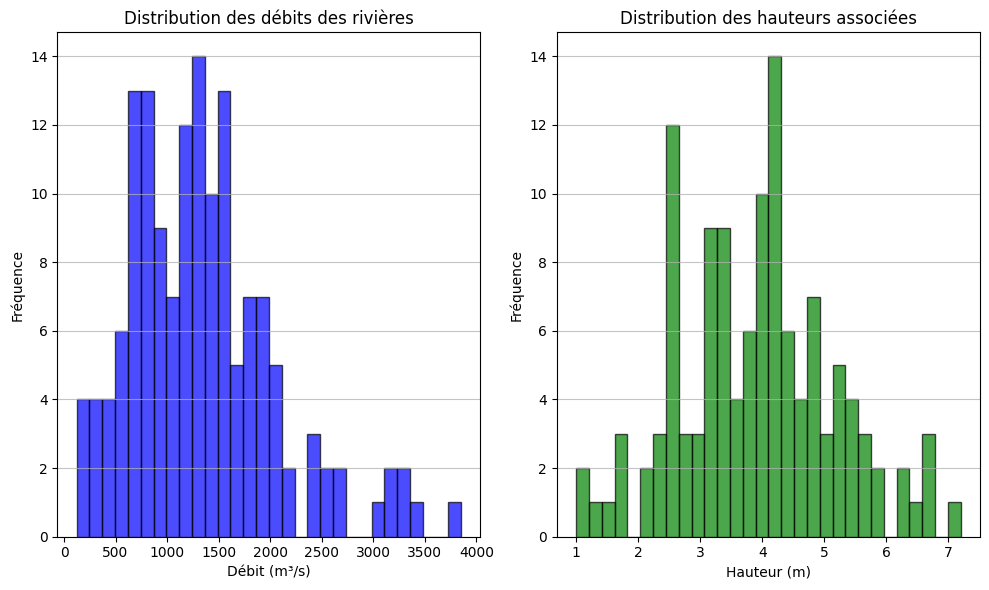

In [185]:
# Affichage de la distribution des données dans un seul graphique

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)

plt.hist(df_rivieres['Debit'], bins=30, alpha=0.7
            , color='blue', edgecolor='black')
plt.title('Distribution des débits des rivières')
plt.xlabel('Débit (m³/s)')
plt.ylabel('Fréquence')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 2, 2)
plt.hist(df_rivieres['Hauteur'], bins=30, alpha=0.7
            , color='green', edgecolor='black')
plt.title('Distribution des hauteurs associées')
plt.xlabel('Hauteur (m)')
plt.ylabel('Fréquence')
plt.grid(axis='y', alpha=0.75)



plt.tight_layout()
savefig("distributions_debit_hauteur.png")
plt.show()


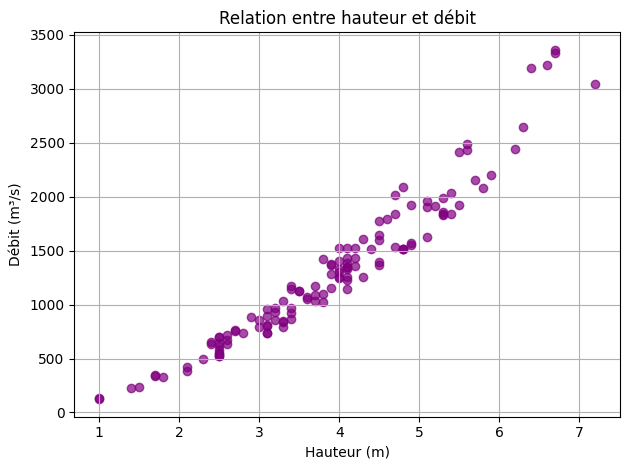

In [186]:
plt.scatter(df_rivieres['Hauteur'], df_rivieres['Debit'], alpha=
            0.7, color='purple')
plt.title('Relation entre hauteur et débit')
plt.xlabel('Hauteur (m)')
plt.ylabel('Débit (m³/s)')
plt.grid()

plt.tight_layout()

plt.show()

saved -> reports/figures/approche1/evolution_debit_hauteur.png


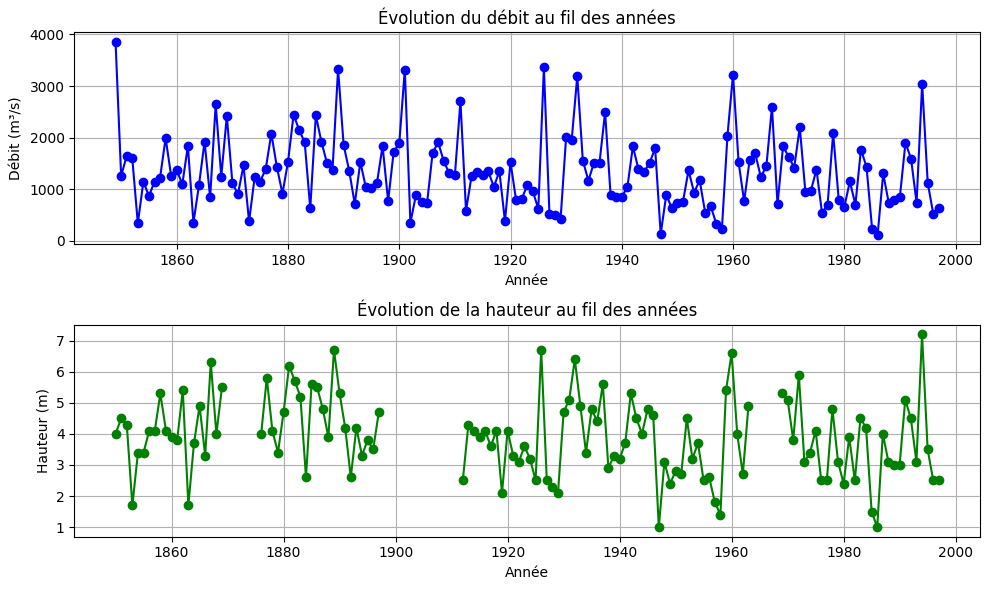

In [187]:
# Il y a t'il une evolution dans le temps ?
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(df_rivieres['Annee'], df_rivieres['Debit'], marker='o', linestyle='-', color='blue')
plt.title('Évolution du débit au fil des années')
plt.xlabel('Année')
plt.ylabel('Débit (m³/s)')
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(df_rivieres['Annee'], df_rivieres['Hauteur'], marker='o', linestyle='-', color='green')
plt.title('Évolution de la hauteur au fil des années')
plt.xlabel('Année')
plt.ylabel('Hauteur (m)')
plt.grid()
plt.tight_layout()
savefig("evolution_debit_hauteur.png")
plt.show()

In [188]:
# Colonnes numériques à résumer
cols = ["Debit", "Hauteur"]

# Fonction de stats "propres"
def resume_stats(serie: pd.Series) -> dict:
    x = serie.dropna().astype(float)
    return {
        "n": int(x.shape[0]),
        "nb_NaN": int(serie.isna().sum()),
        "min": float(x.min()),
        "q25": float(x.quantile(0.25)),
        "médiane": float(x.median()),
        "moyenne": float(x.mean()),
        "q75": float(x.quantile(0.75)),
        "max": float(x.max()),
        "variance (échantillon)": float(x.var(ddof=1)),
        "écart-type (échantillon)": float(x.std(ddof=1)),
    }

# Tableau récapitulatif
df_stats = pd.DataFrame({col: resume_stats(df_rivieres[col]) for col in cols}).T

# Affichage propre (arrondi)
display(df_stats.round(3))

,n,nb_NaN,min,q25,médiane,moyenne,q75,max,variance (échantillon),écart-type (échantillon)
Debit,149.0,0.0,122.436,799.919,1256.402,1335.420,1694.93,3853.893,509691.399,713.927
Hauteur,123.0,26.0,1.000,3.100,3.900,3.897,4.75,7.200,1.619,1.272


## Problème des H manquants : regression lineaire entre Q et H

In [189]:
# Régression linéaire entre débit et hauteur en enlevant les valeurs manquantes
LR = LinearRegression()
train = df_rivieres.dropna(subset=["Hauteur"]).copy()

X_train = train[["Debit"]].values   # variable explicative : Q
y_train = train["Hauteur"].values   # cible : H

LR.fit(X_train, y_train)
print(f"Coefficient de régression (a) : {LR.coef_[0]:.4f}")
print(f"Ordonnée à l'origine (b) : {LR.intercept_:.4f}")


Coefficient de régression (a) : 0.0018
Ordonnée à l'origine (b) : 1.5483


saved -> reports/figures/approche1/regression_debit_hauteur.png


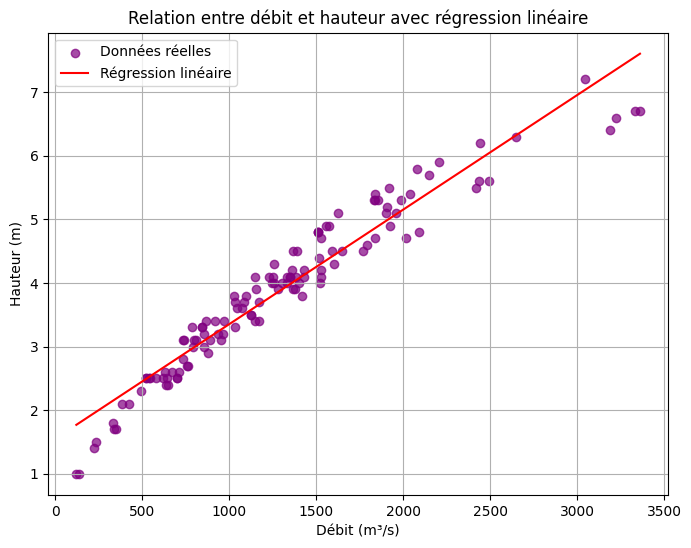

In [190]:
plt.figure(figsize=(8, 6))
plt.scatter(train["Debit"], train["Hauteur"], alpha=0.7, color='purple', label='Données réelles')
x_range = np.linspace(train["Debit"].min(), train["Debit"].max(), 100).reshape(-1, 1)
y_pred = LR.predict(x_range)
plt.plot(x_range, y_pred, color='red', label='Régression linéaire')
plt.title('Relation entre débit et hauteur avec régression linéaire')
plt.xlabel('Débit (m³/s)')
plt.ylabel('Hauteur (m)')
plt.legend()
plt.grid()
savefig("regression_debit_hauteur.png")
plt.show()


In [191]:
# On remplace les valeurs manquantes de "Hauteur" par les prédictions de la régression linéaire
df_rivieres["Hauteur_pred"] = LR.predict(df_rivieres[["Debit"]])

df_rivieres["Hauteur_filled"] = df_rivieres["Hauteur"].fillna(df_rivieres["Hauteur_pred"].round(2))

df_rivieres["Hauteur"] = df_rivieres["Hauteur_filled"]

#On enleve les colonnes intermédiaires
df_rivieres = df_rivieres.drop(columns=["Hauteur_pred", "Hauteur_filled"])

df_rivieres.head()

/Users/thomasrichard/.venvs/vscode/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


,Annee,Debit,Hauteur
0,1849,3853.892756,8.49
1,1850,1256.402143,4.00
2,1851,1648.542191,4.50
3,1852,1604.857094,4.30
4,1853,341.157419,1.70


# 3) 1ere solution naïve : hd tel que max(H) x 1.3 = **11.04 m**

Sans autre informations ou contraintes que les relevés Débit+Hauteur, une première solution empirique serait de construire une digue plus haute que la hauteur maximale observée jusqu'à présent. La majoration de 30% est arbitraire

On note que la **hauteur max est une valeur issue de la régression linéaire**. C'est 1849 qui est aussi l'année avec la plus forte mesure de Débit

In [192]:
hd1 = max(df_rivieres["Hauteur"].values)
print(f"Hauteur maximale : {hd1:.2f} m")

hd1 *= 1.3
print(f"Hauteur de digue proposée (hd1) : {hd1:.2f} m")

Hauteur maximale : 8.49 m
Hauteur de digue proposée (hd1) : 11.04 m


# 4) 2eme solution : fiter une loi de Gumbel sur les données

## Modèle probabiliste

L’idée est de passer d’un **risque annuel** $P(H>h_d)$ à un **objectif sur $n$ années** :  
on veut une digue assez haute pour que la probabilité d’avoir **0 surverse sur $n$ ans** soit très grande (ex : 0.99 ou 0.999).

On suppose que les **maxima annuels** $H$ suivent une loi de **Gumbel** :
$
H \sim \text{Gumbel}(\mu,\beta)
$

On estime $(\mu,\beta)$ par **maximum de vraisemblance (EMV)** à partir des observations de $H$.

Ensuite, on considère $n$ années futures indépendantes :
$
X_1,\dots,X_n \overset{i.i.d.}{\sim} \text{Gumbel}(\hat\mu,\hat\beta)
$
et on définit le maximum sur $n$ ans :
$
Z=\max(X_1,\dots,X_n)
$

Nous cherchons donc **pour quelle valeur de $h_d$ a t'on $P(0$ surverse pendant $n$ années) $> 0.99$ (ou 0.999) i.e. $P(Z>hd) < 0.01$**

Notons qu'ici : 

$Z\{Z \le z\} = \{X_1 \le z, X_2 \le z, \dots, X_n \le z\}$

Donc :  $F_Z(z) = P(Z \le z) = P(X_1 \le z, \dots, X_n \le z)$

Or les $X_i$ sont *i.i.d.*, donc $F_Z(z) = (F_X(z))^n$

Donc il suffit ici de prendre $h_d$ tel que 
$
(F_X(h_d))^n = p
\;\Longleftrightarrow\;
F_X(h_d)=p^{1/n}
\;\Longleftrightarrow\;
h_d = F_X^{-1}\!\left(p^{1/n}\right).
$

## EMV pour les paramêtres de la $Gumbel$ d'une année

In [193]:
# Fit d'une loi de Gumbel (MV) sur la colonne 'Hauteur' ---
H = df_rivieres["Hauteur"].values

# scipy.stats.gumbel_r.fit fait un fit par maximum de vraisemblance
loc_hat, scale_hat = stats.gumbel_r.fit(H)

print(f"Paramètres estimés (MV) : loc = {loc_hat:.4f}, scale = {scale_hat:.4f}")

Paramètres estimés (MV) : loc = 3.3221, scale = 1.1893


saved -> reports/figures/approche1/fit_gumbel_hauteur.png


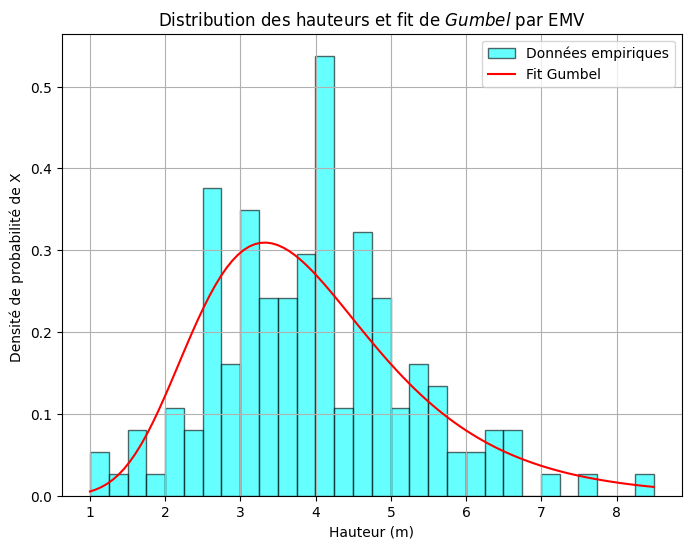

In [194]:
# ploter la distribution empirique et le fit de Gumbel
plt.figure(figsize=(8, 6))
plt.hist(H, bins=30, density=True, alpha=0.6, color='cyan', edgecolor='black', label='Données empiriques')
x = np.linspace(H.min(), H.max(), 100)
pdf_gumbel = stats.gumbel_r.pdf(x, loc=loc_hat, scale=scale_hat)
plt.plot(x, pdf_gumbel, color='red', label='Fit Gumbel')
plt.title('Distribution des hauteurs et fit de $Gumbel$ par EMV')
plt.xlabel('Hauteur (m)')
plt.ylabel('Densité de probabilité de X ')
plt.legend()
plt.grid()
savefig("fit_gumbel_hauteur.png")
plt.show()

## Calcul de $h_d$

In [195]:
n = 100      # nombre d'années
p = 0.99     # probabilité cible : 0 surverse sur n ans

u = p**(1/n)  # u = F_X(h_d)
hd = stats.gumbel_r.ppf(u, loc=loc_hat, scale=scale_hat)

print(f"Pour n={n} ans et p={p}, la hauteur minimale est : h_d = {hd:.4f}")

Pour n=100 ans et p=0.99, la hauteur minimale est : h_d = 14.2701


### Plot de la distribution de $Z$

saved -> reports/figures/approche1/distribution_Z_h_d.png


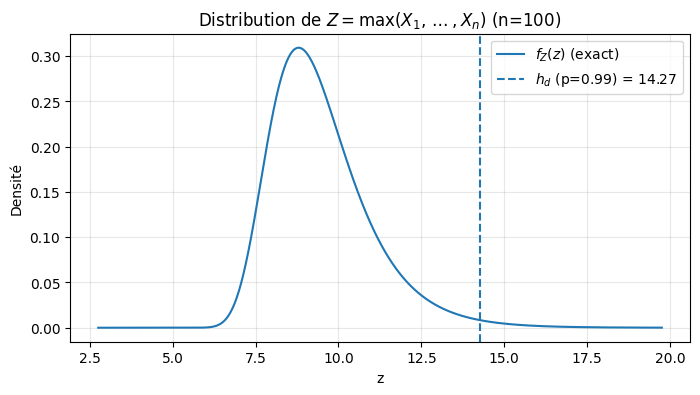

In [196]:
# Grille de z (on prend un intervalle couvrant quasi toute la masse)
z_min = stats.gumbel_r.ppf(0.2, loc=loc_hat, scale=scale_hat)
z_max = stats.gumbel_r.ppf(1-1e-6, loc=loc_hat, scale=scale_hat)
z = np.linspace(z_min, z_max, 2000)

Fx = stats.gumbel_r.cdf(z, loc=loc_hat, scale=scale_hat)
fx = stats.gumbel_r.pdf(z, loc=loc_hat, scale=scale_hat)

Fz = Fx**n
fz = n * fx * (Fx**(n-1))   # densité exacte de Z

plt.figure(figsize=(8,4))
plt.plot(z, fz, label=r"$f_Z(z)$ (exact)")
plt.axvline(hd, linestyle="--", label=fr"$h_d$ (p={p}) = {hd:.2f}")
plt.title(fr"Distribution de $Z=\max(X_1,\dots,X_n)$ (n={n})")
plt.xlabel("z")
plt.ylabel("Densité")
plt.grid(True, alpha=0.3)
plt.legend()
savefig("distribution_Z_h_d.png")
plt.show()

### Plot de la hauteur requise par rapport à P(Z)

saved -> reports/figures/approche1/hd_vs_p.png


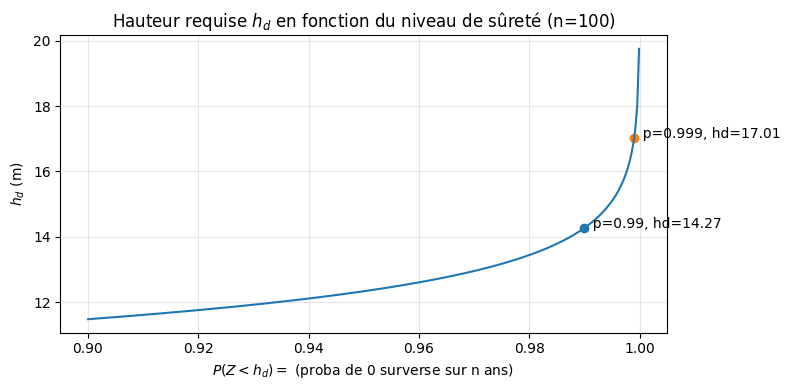

In [197]:
p_grid = np.linspace(0.90, 0.9999, 300)
u_grid = p_grid**(1/n)
hd_grid = stats.gumbel_r.ppf(u_grid, loc=loc_hat, scale=scale_hat)

plt.figure(figsize=(8,4))
plt.plot(p_grid, hd_grid)
plt.grid(True, alpha=0.3)
plt.xlabel(r"$P(Z < h_d) =$ (proba de 0 surverse sur n ans)")
plt.ylabel(r"$h_d$ (m)")
plt.title(fr"Hauteur requise $h_d$ en fonction du niveau de sûreté (n={n})")

for p, hd in zip(p_list, hd_list):
    plt.scatter([p], [hd])
    plt.text(p, hd, f"  p={p}, hd={hd:.2f}")

plt.tight_layout()
savefig("hd_vs_p.png")
plt.show()

# Monte Carlo pour se rassurer

### Approche Monte-Carlo (après fit de Gumbel)




#### 4) Procédure Monte-Carlo (ce que fait le code)
On fixe :
- $n$ = nombre d’années (ex. $n=100$),
- $N$ = nombre de répétitions Monte-Carlo (ici $N=200000$).

Puis :
1. On simule une matrice $X$ de taille $N \times n$ :
   $
   X^{(k)}_1,\dots,X^{(k)}_n \sim \text{Gumbel}(\hat\mu,\hat\beta)
   $
2. Pour chaque répétition $k$, on calcule :
   $
   Z^{(k)}=\max(X^{(k)}_1,\dots,X^{(k)}_n)
   $
3. On obtient un échantillon $\{Z^{(1)},\dots,Z^{(N)}\}$ qui approxime la loi de $Z$.
4. On estime le seuil $h_d$ comme un **quantile** :
   $
   h_{d,0.99} \approx \text{Quantile}_{0.99}(Z),\qquad
   h_{d,0.999} \approx \text{Quantile}_{0.999}(Z)
   $

Interprétation :  $h_{d,0.99}$ est la hauteur telle que $P(Z \le h_d)\approx 0.99$, donc **≈ 99% de chances de n’avoir aucune surverse sur 100 ans**.

Seuil Monte-Carlo : hd_0.99  (P(Z <= hd)=0.99)  ≈ 14.2440 m
Seuil Monte-Carlo : hd_0.999 (P(Z <= hd)=0.999) ≈ 16.9488 m
saved -> reports/figures/approche1/distribution_Z_monte_carlo.png


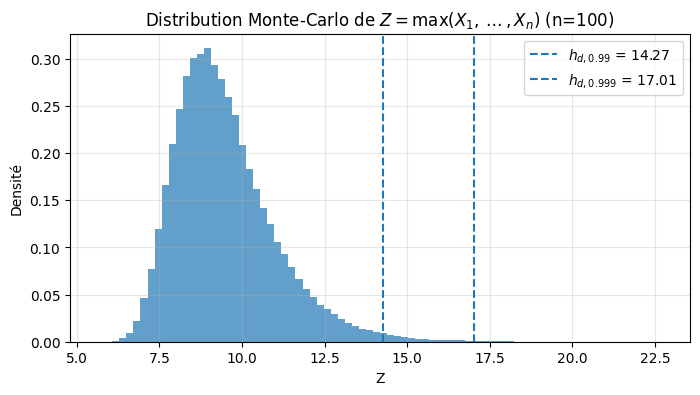

In [198]:
np.random.seed(42)

n_annee = 100       # Z = max de 100 variables Gumbel = 100 années
n_mc = 200000     # nb de répétitions Monte-Carlo pour estimer P(Z > hd)

# Simulation Monte-Carlo de Z = max(X1,...,X100) où Xi ~ Gumbel(loc_hat, scale_hat)
X = stats.gumbel_r.rvs(loc=loc_hat, scale=scale_hat, size=(n_mc, n_annee))
Z_mc = X.max(axis=1) # 200000 réalisations de Z = max(X1,...,X100)
# Seuil monte carlo 
hd_99_mc   = np.quantile(Z_mc, 0.99)
hd_999_mc  = np.quantile(Z_mc, 0.999)

print(f"Seuil Monte-Carlo : hd_0.99  (P(Z <= hd)=0.99)  ≈ {hd_99_mc:.4f} m")
print(f"Seuil Monte-Carlo : hd_0.999 (P(Z <= hd)=0.999) ≈ {hd_999_mc:.4f} m")

plt.figure(figsize=(8,4))
plt.hist(Z_mc, bins=80, density=True, alpha=0.7)
for p, hd in zip(p_list, hd_list):
    plt.axvline(hd, linestyle="--", label=fr"$h_{{d,{p}}}$ = {hd:.2f}")
plt.title(fr"Distribution Monte-Carlo de $Z=\max(X_1,\dots,X_n)$ (n={n})")
plt.xlabel("Z")
plt.ylabel("Densité")
plt.grid(True, alpha=0.3)
plt.legend()
savefig("distribution_Z_monte_carlo.png")
plt.show()